# 1. Gaussian amplitudes and simulated samples

We construct a positive interference model with known densities and derivatives.
This provides an analytical benchmark for learned density ratios, unbinned
likelihoods, and parameterized score histograms. Run this notebook first.

Five million events per S/SBI/B sample and fifty million per NI/NI-up/NI-down
sample provide Monte Carlo precision; the
expected event yields of the statistical experiment are separate quantities.
This benchmark is designed to make interference and nuisance effects visible;
it illustrates the method and is not a numerical reproduction of an ATLAS
measurement. The second branch remains below \(\mu=1\), while S now has a visibly
different shape from B. The generating signal strength is \(\mu_*=1\).

### Runtime and persistent run

In Colab, choose **Runtime → Change runtime type → GPU** for notebooks 2–3.
Both PyTorch training and JAX likelihood fits use the GPU when available.
`JAX_BACKEND = "auto"` detects the Colab NVIDIA GPU; choose `"gpu"` to require it,
or `"cpu"` for an explicit CPU run. Setup installs matching JAX/JAXlib and CUDA 12
plugin packages, then checks double-precision JIT computation and gradients on
the selected device before training. GPU initialization failures are reported
instead of silently switching to CPU. Restart the runtime once when switching
from the previous CPU-only setup or after a JAX plugin error.
For a runtime-only repair, keep the same run name: saved samples and trained
networks are reused. A changed physics model requires a new run, as below.
The source checkout lives in the temporary runtime; **datasets, checkpoints,
workspace files, and results live in Google Drive**. Use the same `RUN_NAME`
and `MODE` in every notebook. Set `MODE = "smoke"` for a short workflow check;
production generates five million events each for S, SBI and B, and fifty
million each for NI, NI_up and NI_down.
Use `CONFIG_OVERRIDES` to change a computational budget without editing source,
for example `{"quadrature_per_process": 500_000, "epochs": 150}`. Use the same
overrides in all notebooks, and choose a new `RUN_NAME` when changing them.

This repository may be private. Grant Colab access when opening it from GitHub.
For the runtime download, either save a GitHub fine-grained token with **Contents:
read** access to this repository as the Colab secret `GITHUB_TOKEN`, or enter it
in the hidden prompt. The token is used only in a Python HTTP header and is not
written into files, Git remotes, shell arguments, or notebook output. Alternatively,
upload a repository ZIP to `/content/poodemo_source.zip`; no token is then needed.
An existing `/content/poodemo` checkout is reused. Delete that checkout to fetch
new source after updating the repository; your Drive run is separate.
For the enlarged NI bank and wider ratio classifiers, use the new default
`RUN_NAME = "paper-distinct-s-v4"`. Rerun notebooks 01–03; then rerun 04–09
to refresh their downstream results. The physics amplitudes are unchanged, but
the sample/training configuration is new (schema 7). Start a fresh Colab runtime
or refresh the temporary source checkout and restart it before proceeding.
Use the same new run name in every notebook; previous Drive runs remain intact.

In [1]:
import os
import sys
from pathlib import Path

RUN_NAME = "paper-distinct-s-v4"
MODE = os.environ.get("POODEMO_MODE", "production")  # production or smoke
CONFIG_OVERRIDES = {}  # e.g. {"quadrature_per_process": 500_000, "epochs": 150}
JAX_BACKEND = os.environ.get("POODEMO_JAX_BACKEND", "auto")  # auto, gpu, or cpu

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    requested_backend = JAX_BACKEND.strip().lower()
    if requested_backend not in ("auto", "gpu", "cpu"):
        raise ValueError("JAX_BACKEND must be auto, gpu, or cpu")
    selected_backend = requested_backend
    if requested_backend == "auto":
        try:
            gpu_probe = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                                       capture_output=True, text=True, timeout=10)
            gpu_present = gpu_probe.returncode == 0 and bool(gpu_probe.stdout.strip())
        except (OSError, subprocess.TimeoutExpired):
            gpu_present = False
        selected_backend = "gpu" if gpu_present else "cpu"
    # CUDA-only selection fails visibly if initialization fails. Keep PyTorch's
    # CUDA visibility and avoid JAX reserving most GPU memory before training.
    jax_platform = "cuda" if selected_backend == "gpu" else "cpu"
    os.environ["JAX_PLATFORMS"] = jax_platform
    os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    ROOT = Path(os.environ.get("POODEMO_ROOT", f"/content/drive/MyDrive/poodemo/runs/{RUN_NAME}"))
    REPO_DIR = Path("/content/poodemo")
    if not (REPO_DIR / "pyproject.toml").exists():
        import getpass
        import io
        import shutil
        import tarfile
        import tempfile
        import urllib.error
        import urllib.request
        import zipfile

        uploaded_zip = Path("/content/poodemo_source.zip")
        if uploaded_zip.exists():
            archive_bytes = uploaded_zip.read_bytes()
            archive_kind = "zip"
        else:
            archive_url = "https://api.github.com/repos/rafaellopesdesa/poodemo/tarball/main"

            def fetch_source(token=None):
                headers = {"Accept": "application/vnd.github+json", "User-Agent": "poodemo-colab"}
                if token:
                    headers["Authorization"] = "Bearer " + token
                request = urllib.request.Request(archive_url, headers=headers)
                with urllib.request.urlopen(request, timeout=180) as response:
                    return response.read()

            try:
                archive_bytes = fetch_source()
            except urllib.error.HTTPError as error:
                if error.code not in (401, 403, 404):
                    raise RuntimeError(f"Repository download failed (HTTP {error.code}).") from None
                token = None
                try:
                    from google.colab import userdata
                    token = userdata.get("GITHUB_TOKEN")
                except Exception:
                    pass
                if not token:
                    token = getpass.getpass("GitHub token with read access to poodemo: ").strip()
                if not token:
                    raise RuntimeError("Upload /content/poodemo_source.zip or provide read access.")
                try:
                    archive_bytes = fetch_source(token)
                except urllib.error.HTTPError as auth_error:
                    raise RuntimeError(f"Repository download failed (HTTP {auth_error.code}); check token access.") from None
                finally:
                    token = None
            archive_kind = "tar"

        # Validate archive paths and reject links before extracting the source.
        with tempfile.TemporaryDirectory(prefix="poodemo-source-") as temp:
            staging = Path(temp).resolve()

            def safe_destination(name):
                destination = (staging / name).resolve()
                if not destination.is_relative_to(staging):
                    raise RuntimeError("Unsafe path in source archive.")
                return destination

            if archive_kind == "zip":
                with zipfile.ZipFile(io.BytesIO(archive_bytes)) as archive:
                    for entry in archive.infolist():
                        safe_destination(entry.filename)
                        if (entry.external_attr >> 16) & 0o170000 == 0o120000:
                            raise RuntimeError("Symbolic links are not supported in the source ZIP.")
                    archive.extractall(staging)
            else:
                with tarfile.open(fileobj=io.BytesIO(archive_bytes), mode="r:gz") as archive:
                    for entry in archive.getmembers():
                        safe_destination(entry.name)
                        if not (entry.isfile() or entry.isdir()):
                            raise RuntimeError("Links and special files are not supported in the source archive.")
                    archive.extractall(staging)
            candidates = [p.parent for p in staging.rglob("pyproject.toml") if (p.parent / "poodemo").is_dir()]
            if len(candidates) != 1:
                raise RuntimeError("The uploaded archive must contain one poodemo repository checkout.")
            shutil.copytree(candidates[0], REPO_DIR, dirs_exist_ok=True)
        del archive_bytes

    if os.environ.get("POODEMO_SKIP_INSTALL") != "1":
        from importlib.metadata import version, PackageNotFoundError
        # JAX discovers every installed plugin, even when selecting CPU.
        # Retain already-matched CUDA 12 packages when rerunning GPU setup.
        remove_plugins = []
        for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt", "jax-cuda13-plugin", "jax-cuda13-pjrt"):
            try:
                installed_version = version(package)
            except PackageNotFoundError:
                continue
            if not (selected_backend == "gpu" and package.startswith("jax-cuda12-") and installed_version == "0.5.3"):
                remove_plugins.append(package)
        if remove_plugins:
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "-q", *remove_plugins])
        gpu_requirements = (["jax==0.5.3", "jaxlib==0.5.3",
                             "jax-cuda12-plugin[with-cuda]==0.5.3", "jax-cuda12-pjrt==0.5.3"]
                            if selected_backend == "gpu" else [])
        # Resolve with the base requirements so PyTorch's CUDA dependencies are
        # considered together with JAX's. Avoid blanket --upgrade changes.
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r",
                               str(REPO_DIR / "requirements-colab.txt"), *gpu_requirements])
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR)])

        # Check the live notebook kernel before any expensive network training.
        import jax
        import jaxlib
        import jax.numpy as jnp
        if jax.__version__ != "0.5.3" or jaxlib.__version__ != "0.5.3":
            raise RuntimeError("JAX packages are stale in this kernel. Restart the runtime and rerun setup.")
        if selected_backend == "gpu":
            for package in ("jax-cuda12-plugin", "jax-cuda12-pjrt"):
                if version(package) != "0.5.3":
                    raise RuntimeError(f"{package} must match JAX 0.5.3. Restart the runtime and rerun setup.")
        jax.config.update("jax_platforms", jax_platform)
        jax.config.update("jax_enable_x64", True)
        try:
            jax_devices = jax.devices()
            if not jax_devices or any(device.platform != selected_backend for device in jax_devices):
                raise RuntimeError(f"Expected {selected_backend} devices; found {jax_devices}")
            probe_value, probe_gradient = jax.jit(jax.value_and_grad(lambda x: jnp.sum(x*x)))(
                jnp.asarray([1., 2., 3.], dtype=jnp.float64))
            probe_gradient.block_until_ready()
            if (float(probe_value) != 14. or list(probe_gradient) != [2., 4., 6.]
                    or probe_gradient.dtype != jnp.float64
                    or any(device.platform != selected_backend for device in probe_gradient.devices())):
                raise RuntimeError("JAX double-precision value/gradient check failed")
        except Exception as error:
            raise RuntimeError(
                f"JAX {selected_backend} startup failed. Select a Colab GPU runtime if requesting GPU, "
                "then restart the runtime and rerun setup. Use JAX_BACKEND='cpu' only for an intentional CPU run."
            ) from error
        print(f"JAX {jax.__version__} / jaxlib {jaxlib.__version__}: backend={selected_backend}, {jax_devices}; float64 JIT/gradient OK")

    # A new editable install is not activated in an already-running kernel.
    # Expose the inner package directly, including after a failed import cached
    # the outer /content/poodemo checkout as a namespace package.
    import importlib
    source_root = str(REPO_DIR.resolve())
    if source_root in sys.path:
        sys.path.remove(source_root)
    sys.path.insert(0, source_root)
    importlib.invalidate_caches()
    cached_package = sys.modules.get("poodemo")
    cached_file = getattr(cached_package, "__file__", None)
    expected_init = REPO_DIR / "poodemo" / "__init__.py"
    if cached_package is not None and (cached_file is None or Path(cached_file).resolve() != expected_init.resolve()):
        for module_name in list(sys.modules):
            if module_name == "poodemo" or module_name.startswith("poodemo."):
                del sys.modules[module_name]
else:
    # Locally: pip install -r requirements-colab.txt && pip install -e .
    ROOT = Path(os.environ.get("POODEMO_ROOT", str(Path.home() / "poodemo-runs" / RUN_NAME)))
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "poodemo" / "pipeline.py").exists():
            sys.path.insert(0, str(candidate))
            break

ROOT.mkdir(parents=True, exist_ok=True)
print(f"Run directory: {ROOT}")
print(f"Mode: {MODE}")

Mounted at /content/drive


/tmp/ipykernel_4753/3728892442.py:110: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  archive.extractall(staging)


JAX 0.5.3 / jaxlib 0.5.3: backend=cpu, [CpuDevice(id=0)]; float64 JIT/gradient OK
Run directory: /content/drive/MyDrive/poodemo/runs/paper-distinct-s-v4
Mode: production


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from poodemo.pipeline import create_run

run = create_run(ROOT, mode=MODE, overrides=CONFIG_OVERRIDES)
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.2})
display(pd.Series(run.config, name="configuration"))

,configuration
schema_version,7
mode,production
seed,20261006
physics_overrides,{}
toolkit_commit,fc09848fc6540fd32310faebbe9db6eea7ecd17b
n_per_sample,5000000
ni_sample_multiplier,10
generation_chunk,250000
preselection_train_cap,1000000
ratio_train_cap,2000000


### Amplitudes, densities, and yields

Let \(\phi_j(x)=\mathcal N_3(x;m_j,\Sigma_j)\), normalized to one.
Define amplitudes
\[
A_S(x)=\sqrt{\lambda_S\phi_S(x)},\qquad
A_B(x)=e^{i\varphi}\sqrt{\lambda_B\phi_B(x)},
\qquad A_{NI}(x)=\sqrt{\lambda_{NI}\phi_{NI}(x)}.
\]
Their square roots are Gaussian functions, so these are Gaussian
wavefunctions. The configured phase gives destructive interference.
The means, positive-definite covariance matrices, phase, and inclusive
yields are displayed below and saved with this run. S has a higher
mean and narrower widths than B; SBI remains close to B because the
coherent process is background dominated. The model was retuned to
retain a secondary minimum **below 1**, without requiring it near 0.5.
In an independent analytical-selector validation, the secondary minimum
is near 0.120 with NI fixed and 0.069 with NI profiled; the primary
minimum is at 1. A trained selector can shift these values. The
full-space analytical likelihood also has a secondary minimum.

The exposure is now 50, independently of generated sample counts.
The scan starts at 0.02 to include the second basin. The bounded-score
scale is 0.04, adapted to its broader distribution, so later comparisons
do not saturate the old score transformation.

The coherent process at \(\mu=1\) is
\[
D_{SBI}=|A_S+A_B|^2=D_S+D_B+D_I,
\quad D_I=2\cos\varphi\sqrt{D_SD_B}.
\]
The SBI density is \(p_{SBI}=D_{SBI}/\lambda_{SBI}\), with
\(\lambda_{SBI}=\int D_{SBI}\,dx\). It is **not** assigned an arbitrary
yield: interference fixes its normalization. NI is added incoherently.

At any \(\mu\ge0\),
\[
D(x;\mu)=|\sqrt\mu A_S+A_B|^2+D_{NI}
= (\mu-\sqrt\mu)D_S+\sqrt\mu D_{SBI}
  +(1-\sqrt\mu)D_B+D_{NI}.
\]
The negative coefficients in this basis are physical algebra; the total
amplitude model remains positive.

Destructive interference alone does **not** guarantee a second likelihood
minimum. Its visibility also depends on the signal/background shapes,
selection, event rates, and scanned parameter range. Shape information
can separate two hypotheses with the same total expected yield. Notebook
3 measures the actual unbinned likelihood landscape after preselection.

### Shape uncertainties and statistically independent roles

The only nuisance is \(\alpha_{NI}\). Its ±1 anchors shift the NI
amplitude mean along the configured direction with the configured
magnitude. The actual shift vector is displayed below, so its strength
remains explicit when the benchmark is changed.
S, B, and their coherent SBI process are fixed with respect to this
nuisance. The exact NI shift vector and all model settings are saved in
the run configuration. The inclusive NI yield stays fixed; its selected
yield may change because the selection efficiency changes.

This gives six samples: S, B, SBI, NI, NI_up, and NI_down. Production mode
generates 5 million events each for S, B and SBI, and 50 million each for
NI, NI_up and NI_down: 165 million three-dimensional events in total.
The NI multiplier compensates for its lower selection acceptance without
changing any physical yield. Before any
learning or selection, each sample is divided into seven independent
roles:

| Role | Fraction |
|---|---:|
| Preselection training | 20% |
| Preselection validation | 5% |
| Selection threshold calibration | 5% |
| Density-ratio training | 40% |
| Density-ratio validation | 10% |
| Density-ratio calibration | 5% |
| Final integration | 15% |

Events used to train or tune the selector are never reused for the
subsequent ratio-training or inference stages. A sample's Monte Carlo
size does not change its physical yield.

In [3]:
display(pd.Series(run.model.to_dict(), name="amplitude model"))
display(pd.DataFrame({
    "process": ["S", "SBI", "B", "NI"],
    "inclusive_yield": [run.model.component_yield(p) for p in ["S", "SBI", "B", "NI"]],
}))
ni_nominal_mean = run.model.mean("NI", alpha_ni=0.)
ni_shift = run.model.mean("NI", alpha_ni=1.) - ni_nominal_mean
print("NI mean at alpha=0:", ni_nominal_mean)
print("NI +1 sigma mean displacement:", ni_shift)
print("Displacement magnitude:", np.linalg.norm(ni_shift))
print("Expected-yield exposure multiplier:", run.model.exposure)

,amplitude model
lambda_s,100.0
lambda_b,1000.0
lambda_ni,10000.0
exposure,50.0
phase_cos,-0.24
mean_s,"[1.5, 1.1, 0.7]"
mean_b,"[1.2225921266211124, 0.9018515190650804, 0.620..."
mean_ni,"[-0.6, -0.4, 0.1]"
cov_s,"[[0.72, 0.18, 0.06], [0.18, 0.64, 0.1], [0.06,..."
cov_b,"[[0.9, 0.225, 0.075], [0.225, 0.8, 0.125], [0...."


,process,inclusive_yield
0,S,5000.000000
1,SBI,47594.142762
2,B,50000.000000
3,NI,500000.000000


NI mean at alpha=0: [-0.6 -0.4  0.1]
NI +1 sigma mean displacement: [0.17310513 0.12364652 0.04945861]
Displacement magnitude: 0.21840329667841557
Expected-yield exposure multiplier: 50.0


In [4]:
from poodemo.pipeline import generate_data

sample_summary = generate_data(run)
display(sample_summary)

S: 5,000,000 events ready
SBI: 5,000,000 events ready
B: 5,000,000 events ready
NI: 50,000,000 events ready
NI_up: 50,000,000 events ready
NI_down: 50,000,000 events ready


,sample,events,expected_yield,megabytes
0,S,5000000,5000.000000,60.000128
1,SBI,5000000,47594.142762,60.000128
2,B,5000000,50000.000000,60.000128
3,NI,50000000,500000.000000,600.000128
4,NI_up,50000000,500000.000000,600.000128
5,NI_down,50000000,500000.000000,600.000128


### Shape and expected-yield views

The first figure overlays normalized S, SBI, B and NI marginals in
linear and logarithmic views. Exact model bin averages are shown as
steps, with a subset of generated MC as markers. The log panels expose
tail differences without relying on sparsely populated MC bins.

The next figures show expected yields at mu=0, 0.5, 1 and 2, before
preselection. Each stack contains the positive coherent SBI(mu) sum
and NI. Signed S/SBI/B basis terms are combined **before** stacking.
At mu=0 the coherent component is exactly B. Exact Gaussian marginal
integrals preserve normalization and positivity; no yield is inferred
by subtracting independently fluctuating generated samples.

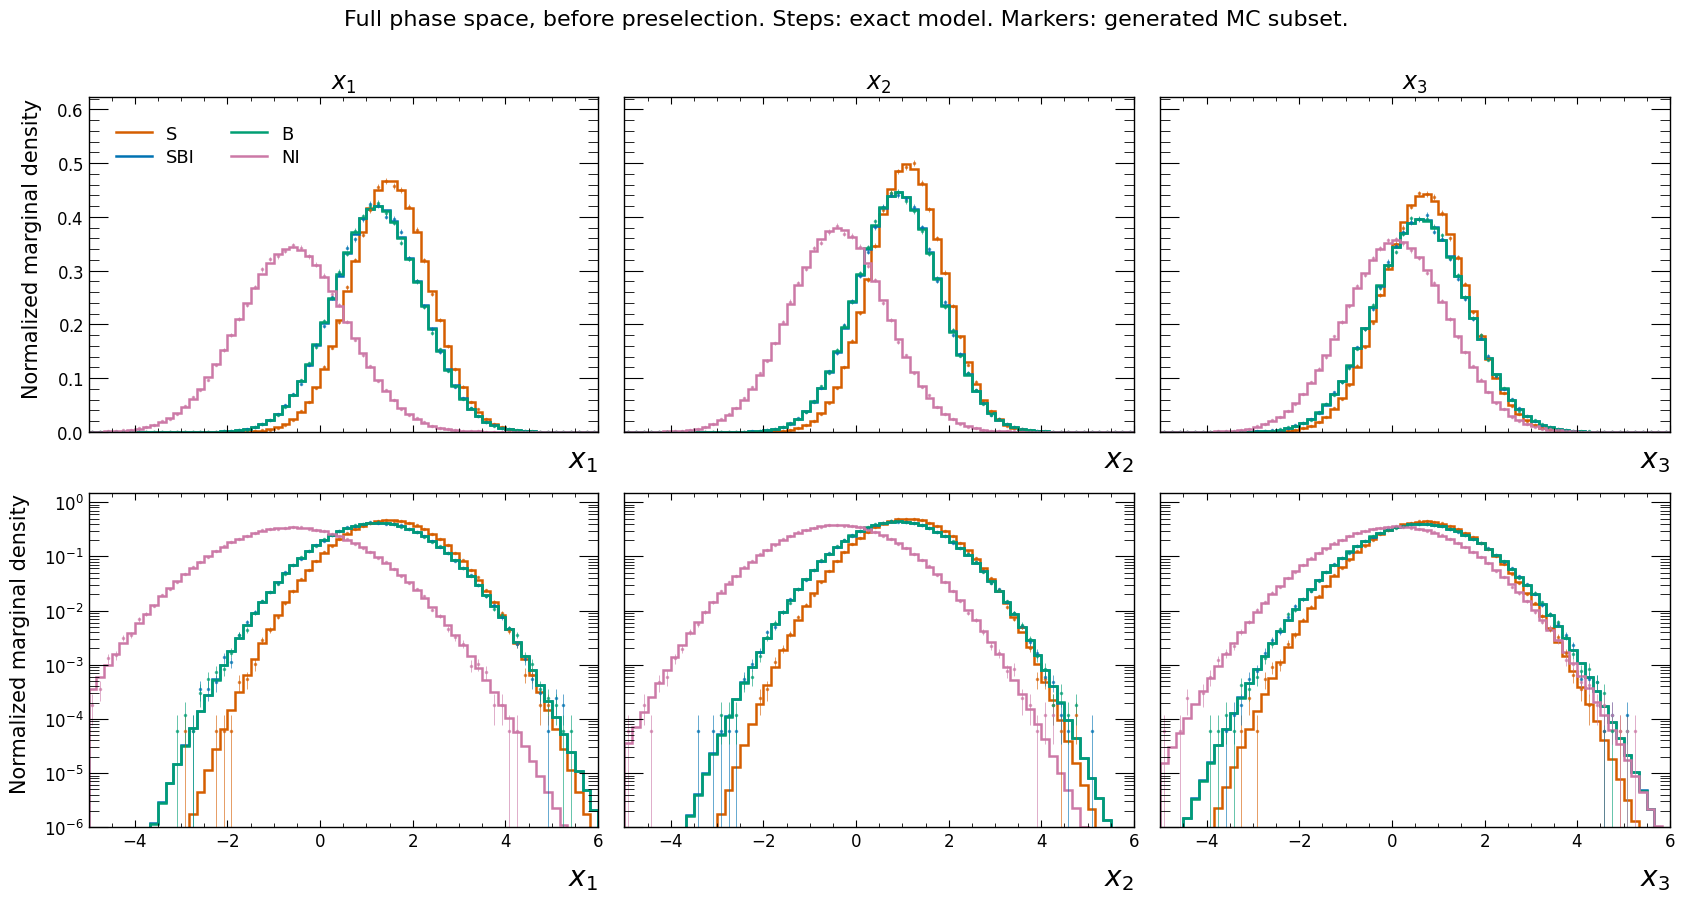

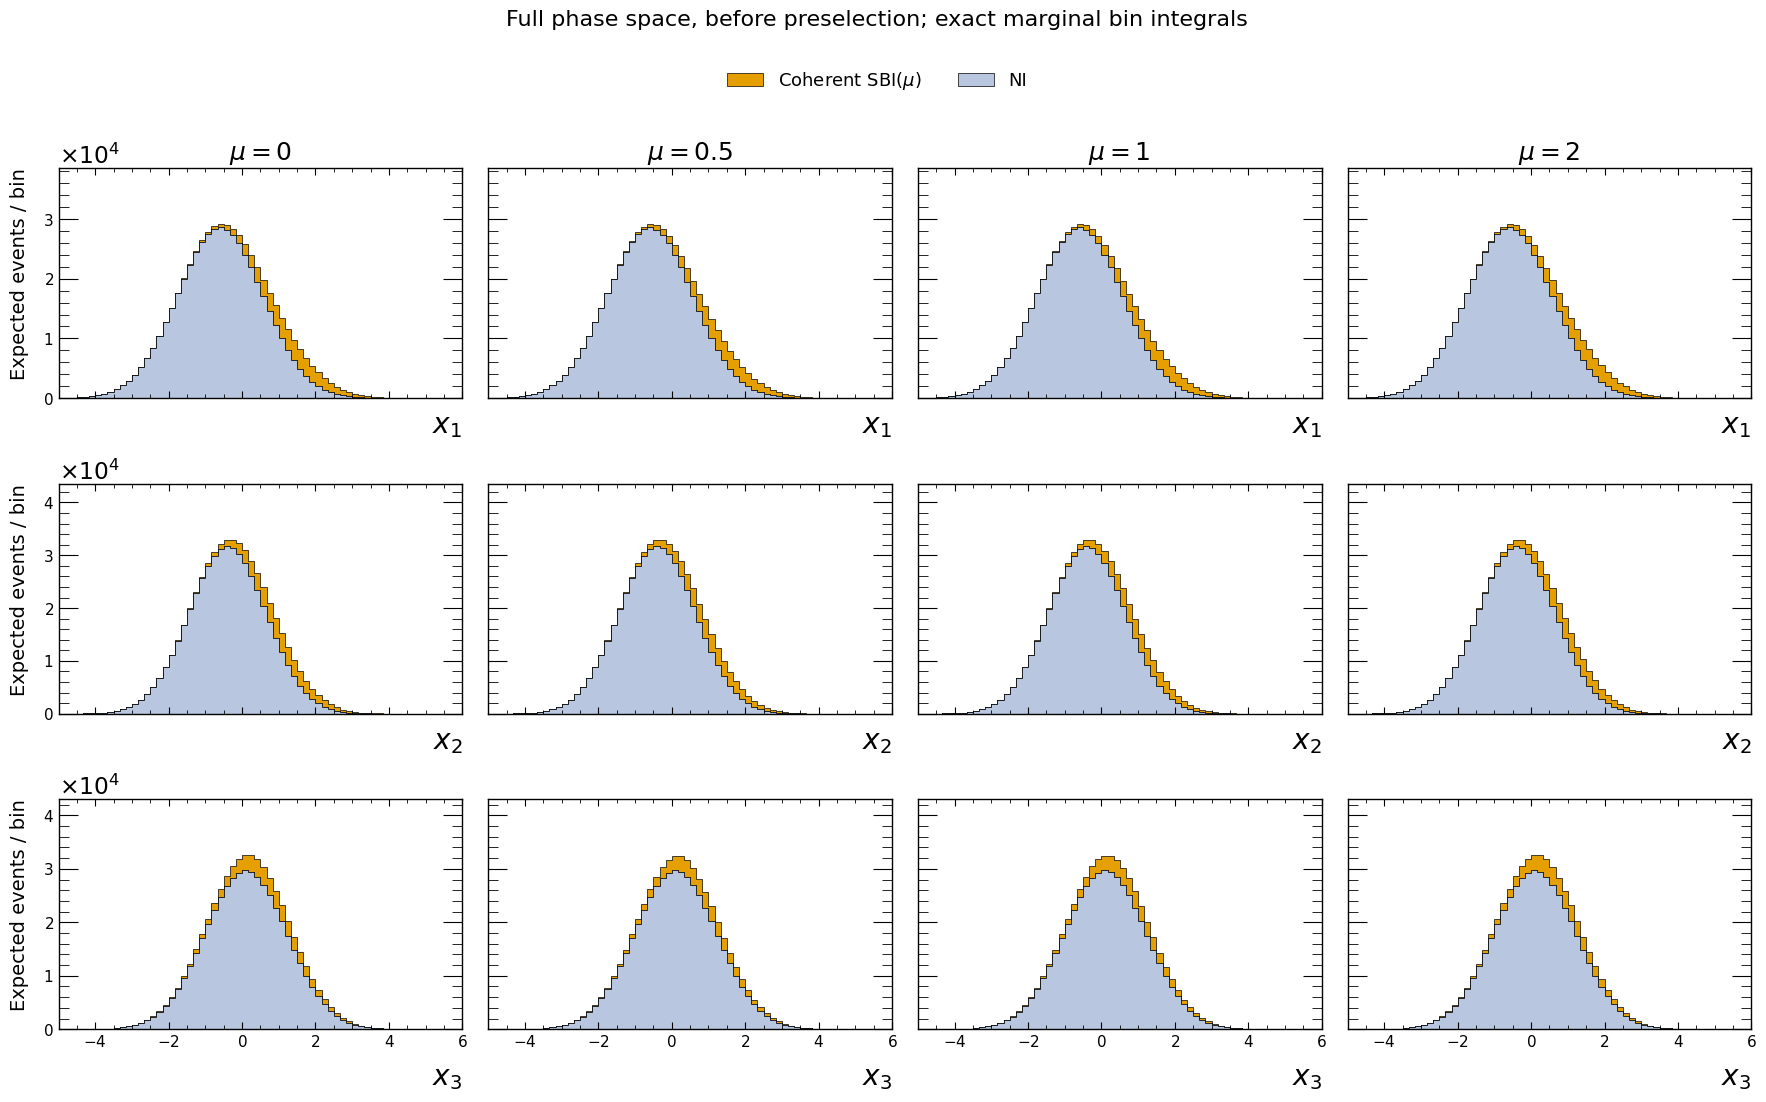

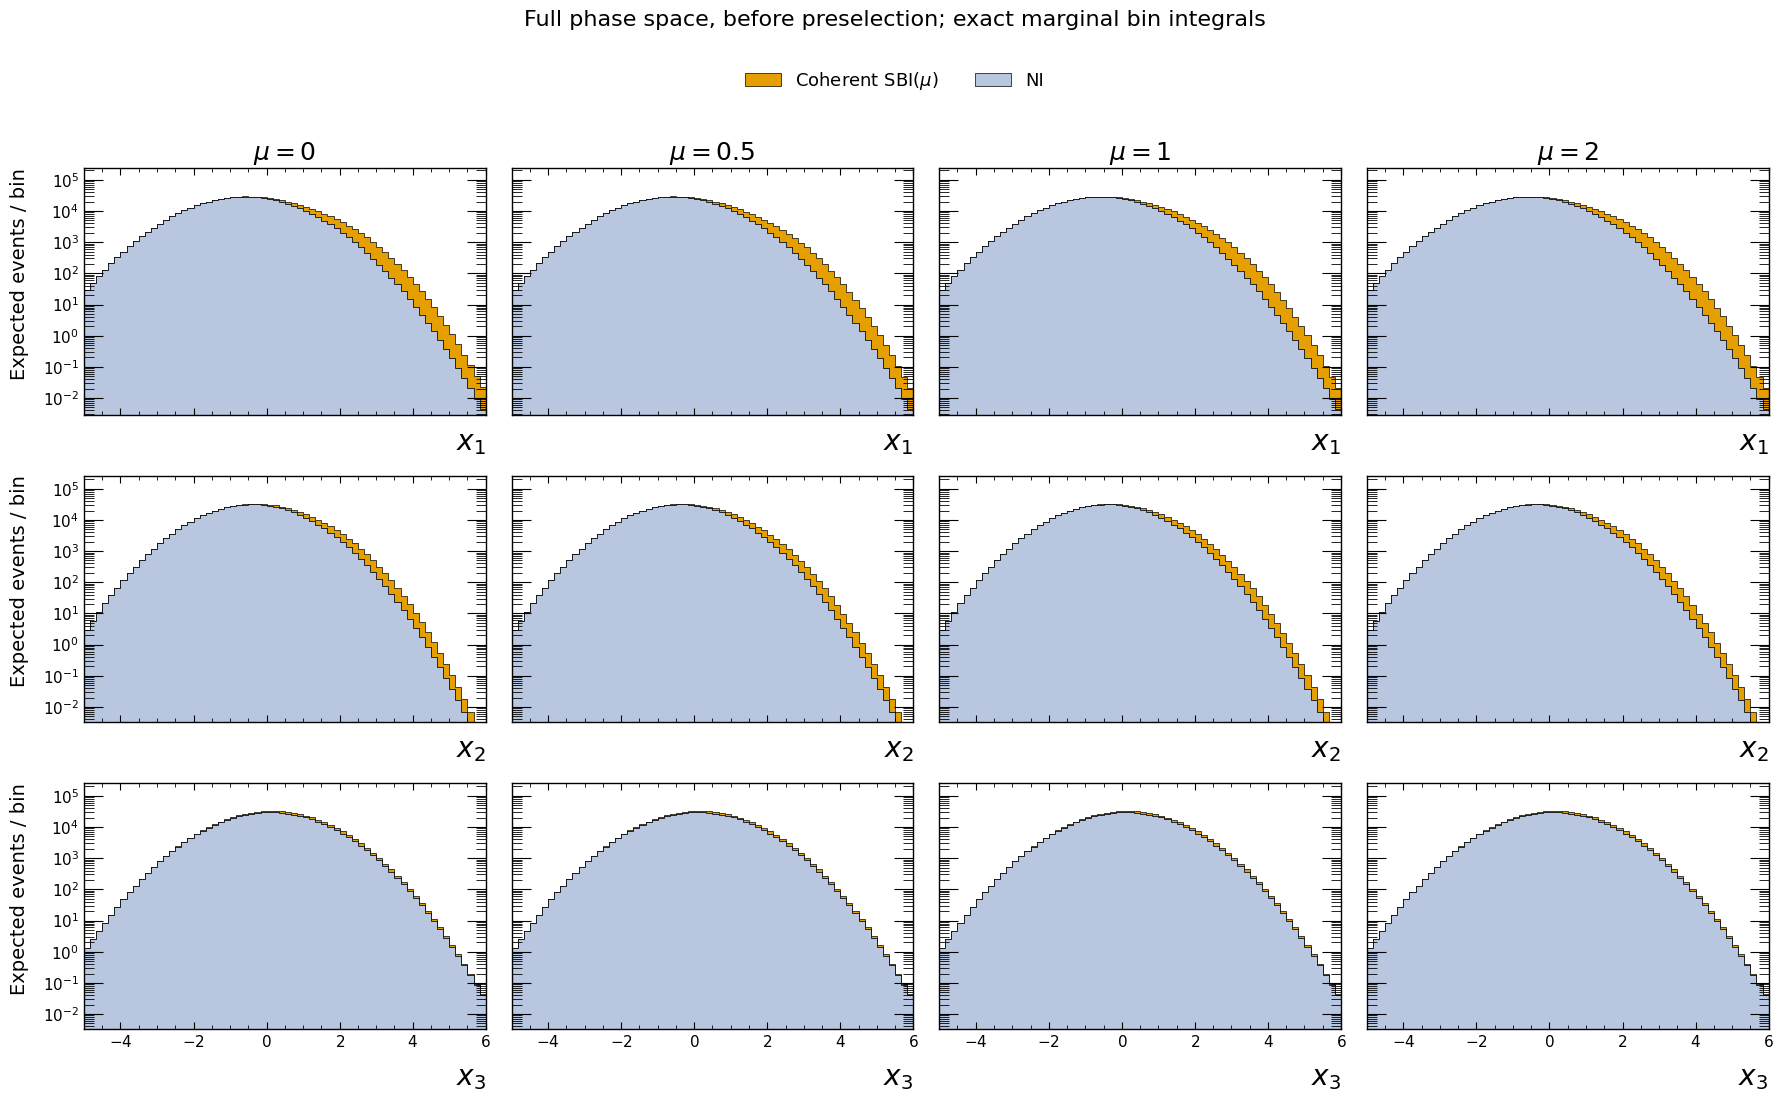

,mu,coherent_SBI_yield,NI_yield,total_yield
0,0.0,50000.000000,500000.0,550000.000000
1,0.5,47263.268127,500000.0,547263.268127
2,1.0,47594.142762,500000.0,547594.142762
3,2.0,49526.536253,500000.0,549526.536253


In [5]:
from poodemo.plotting import plot_process_marginals, plot_coherent_stacks

# Plot-only controls: changing these never regenerates or retrains samples.
PLOT_MAX_EVENTS = 100_000
PLOT_EDGES = np.linspace(-5, 6, 67)  # Extend the range to inspect farther tails.
STACK_MUS = [0., 0.5, 1., 2.]
PLOT_SAMPLES = {
    process: np.load(ROOT / "raw" / f"{process}.npy", mmap_mode="r")[:PLOT_MAX_EVENTS]
    for process in ["S", "SBI", "B", "NI"]
}
plot_process_marginals(run.model, PLOT_EDGES, samples=PLOT_SAMPLES,
                       output=ROOT / "plots")
plt.show()
for log_y in [False, True]:
    plot_coherent_stacks(run.model, PLOT_EDGES, STACK_MUS, log=log_y,
                         output=ROOT / "plots")
    plt.show()

# Full-space yields, not just the finite visible plotting window.
display(pd.DataFrame({
    "mu": STACK_MUS,
    "coherent_SBI_yield": [run.model.total_yield(mu) - run.model.component_yield("NI")
                            for mu in STACK_MUS],
    "NI_yield": run.model.component_yield("NI"),
    "total_yield": [run.model.total_yield(mu) for mu in STACK_MUS],
}))

### Inspect the saved experiment

The generator writes samples in chunks and records normalization and
sampling information. Re-running a completed stage reuses its saved
products; changing the experiment should use a new `RUN_NAME`.
Selected-data and quadrature caches are tied to the selector's
fingerprint, preventing reuse after the selection model changes.
Inspect the summary above for the generated counts and physical yields.
The selected yields in notebook 2 will differ because the classifier cut
has different efficiencies for each process and each systematic anchor.

In [6]:
print("Persistent products:")
for path in sorted(ROOT.iterdir()):
    print(path.name + ("/" if path.is_dir() else ""))

Persistent products:
models/
plots/
quadrature/
raw/
results/
run.json
runtime_environment.json
selected/
workspaces/


Next: open **02_preselection.ipynb** with the same run name and mode.